In [39]:
"""
STR-BUIP Exchange Rate Model Estimation
========================================

This notebook reproduces the main results for:
- STR (Smooth Transition Regression) models
- BUIP (Behavioral UIP) models

All estimation functions are located in src/analysis.py for code organization.
"""

# Core imports
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Local imports
from src.config import config
from src.data_builder import DataBuilder
from src.analysis import build_z_candidates, estimate_all_countries

# Set publication-quality plotting style (black & white)
plt.rcParams.update({
    'figure.dpi': 300,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'font.size': 11,
    'axes.edgecolor': 'black',
    'axes.facecolor': 'white',
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.grid': False,
})

# Base output directory (mode-specific subfolders set after dataset choice)
base_output_dir = config.OUTPUT_DIR

print("=" * 60)
print("STR-BUIP ESTIMATION PIPELINE")
print("=" * 60)
print("\nOutput directories will be configured after dataset selection.")

STR-BUIP ESTIMATION PIPELINE

Output directories will be configured after dataset selection.


## 1. Load and Validate Data

In [40]:
"""
Load Panel Data
---------------
The dataset contains monthly exchange rate and macroeconomic data for 14 countries.
If the data file doesn't exist, it will be automatically built from DBnomics sources.

You can choose between:
- Restricted sample (default): 2000-01 to 2024-12
- Maximum-length sample: longest span with all three key series (S, CPI, policy rate),
  with custom trims for Indonesia, Korea, and Philippines.
Set USE_MAX_DATASET = True to use the maximum-length dataset.
"""

# Choose dataset
USE_MAX_DATASET = True  # <- set to True to use maximum-length dataset

if USE_MAX_DATASET:
    data_path = config.DATA_DIR / "df_panel_max.csv"
else:
    data_path = config.DATA_DIR / "df_panel_final.csv"

if not data_path.exists():
    print("Building dataset from DBnomics...")
    builder = DataBuilder()
    mode = "max" if USE_MAX_DATASET else "restricted"
    df_panel = builder.run(build_mode=mode)
else:
    print(f"Loading existing dataset from {data_path}")
    df_panel = pd.read_csv(data_path, parse_dates=["date"])

# Configure output directories based on selected mode
mode_folder = 'max' if USE_MAX_DATASET else 'restricted'
output_dir = base_output_dir / mode_folder
tables_dir = output_dir / 'tables'
figures_dir = output_dir / 'figures'
agg_fig_dir = figures_dir / 'aggregate'
country_fig_dir = figures_dir / 'country'

for d in [tables_dir, agg_fig_dir, country_fig_dir]:
    d.mkdir(parents=True, exist_ok=True)

print(f"\nOutput directories:")
print(f"  Tables: {tables_dir}")
print(f"  Aggregate Figures: {agg_fig_dir}")
print(f"  Country Figures: {country_fig_dir}")

# Define country list
COUNTRIES = {
    "Australia": "AUS",
    "Brazil": "BRA",
    "Canada": "CAN",
    "Euro Area": "EA",
    "Indonesia": "IND",
    "Japan": "JPN",
    "Korea": "KOR",
    "Mexico": "MEX",
    "New Zealand": "NZL",
    "Philippines": "PHL",
    "Switzerland": "CHE",
    "Thailand": "THA",
    "Türkiye": "TUR",
    "United Kingdom": "GBR"
}

print(f"\nDataset Summary:")
print(f"  Total observations: {len(df_panel):,}")
print(f"  Countries: {len(COUNTRIES)}")
print(f"  Date range: {df_panel['date'].min()} to {df_panel['date'].max()}")
print(f"\nObservations per country:")
print(df_panel['country'].value_counts().sort_index())

Loading existing dataset from /Users/lollo/Documents/Current_Projects/str-buip-estimation/data/df_panel_max.csv

Output directories:
  Tables: /Users/lollo/Documents/Current_Projects/str-buip-estimation/results/max/tables
  Aggregate Figures: /Users/lollo/Documents/Current_Projects/str-buip-estimation/results/max/figures/aggregate
  Country Figures: /Users/lollo/Documents/Current_Projects/str-buip-estimation/results/max/figures/country

Dataset Summary:
  Total observations: 6,721
  Countries: 14
  Date range: 1982-09-30 00:00:00 to 2025-07-31 00:00:00

Observations per country:
country
Australia         512
Brazil            514
Canada            514
Euro Area         318
Indonesia         468
Japan             479
Korea             513
Mexico            514
New Zealand       483
Philippines       472
Switzerland       515
Thailand          434
Türkiye           470
United Kingdom    515
Name: count, dtype: int64


## 2. Descriptive Statistics

Generate summary statistics for exchange rate returns and fundamental values across all countries.

In [41]:
"""
Compute descriptive statistics for:
- Exchange rate returns (r_s)
- Fundamental value (log CPI differential: log(p_dom) - log(p_for))
"""
from scipy import stats as sp_stats

stats_rows = []
for country_name in COUNTRIES.keys():
    sub = df_panel[df_panel['country'] == country_name].copy()
    if len(sub) == 0:
        continue
    
    # Exchange rate returns
    r_s = pd.to_numeric(sub['r_s'], errors='coerce').dropna()
    
    # Fundamental value (log CPI differential)
    fv = (np.log(sub['p_dom']) - np.log(sub['p_for'])).dropna()
    
    stats_rows.append({
        'Country': country_name,
        'Mean_r_s': r_s.mean(),
        'Var_r_s': r_s.var(ddof=1),
        'Skew_r_s': sp_stats.skew(r_s),
        'Kurt_r_s': sp_stats.kurtosis(r_s),
        'Mean_f': fv.mean(),
        'Var_f': fv.var(ddof=1)
    })

df_desc = pd.DataFrame(stats_rows).set_index('Country')
print("\n=== DESCRIPTIVE STATISTICS ===")
print(df_desc.round(4))

# Save outputs
csv_path = tables_dir / 'descriptive_statistics.csv'
tex_path = tables_dir / 'descriptive_statistics.tex'
df_desc.round(4).to_csv(csv_path)

# Create LaTeX version with math formatting
df_desc_latex = df_desc.copy()
df_desc_latex.columns = [
    r'$Mean_{\Delta s}$',
    r'$Var_{\Delta s}$',
    r'$Skew_{\Delta s}$',
    r'$Kurt_{\Delta s}$',
    r'$Mean_{f}$',
    r'$Var_{f}$'
]
with open(tex_path, 'w') as f:
    f.write(df_desc_latex.round(4).to_latex(
        float_format=lambda x: f"{x:.4f}", 
        escape=False, 
        caption='Descriptive Statistics: Exchange Rate Returns & Fundamental Value', 
        label='tab:desc_stats'
    ))

print(f"\n✓ Saved: {csv_path.name}")
print(f"✓ Saved: {tex_path.name}")


=== DESCRIPTIVE STATISTICS ===
                Mean_r_s  Var_r_s  Skew_r_s  Kurt_r_s  Mean_f   Var_f
Country                                                              
Australia         0.0008   0.0010    0.7045    2.5387  0.3314  0.1274
Brazil            0.0488   0.0104    1.6606    3.1150  3.3373  0.8037
Canada            0.0002   0.0004    0.4249    3.9327 -0.0051  0.1346
Euro Area        -0.0000   0.0007    0.1595    1.2867 -0.0919  0.2374
Indonesia         0.0057   0.0037    5.3678   69.4273  1.3997  0.1515
Japan            -0.0010   0.0009   -0.2226    1.3990 -2.0937  0.4672
Korea             0.0012   0.0009    0.7188   12.5920  0.5421  0.3243
Mexico            0.0116   0.0024    6.0905   68.4200  1.8292  0.6185
New Zealand      -0.0005   0.0012    0.3714    1.2110 -0.1009  0.0610
Philippines       0.0038   0.0008    3.5908   25.9394  1.0881  0.2147
Switzerland      -0.0019   0.0010   -0.1025    0.9630 -0.3797  0.4980
Thailand          0.0007   0.0008    0.2737   27.8384  0.2

### 2.1 Raw Series Overview (All Countries)

Three figures (7x2 subplots) showing per-country time series for:
- Exchange rate level `S`
- Domestic CPI `CPI_dom`
- Domestic policy rate `i_dom` (monthly effective)

✓ Saved: raw_series_exchange_rate.png, raw_series_exchange_rate.pdf
✓ Saved: raw_series_cpi_dom.png, raw_series_cpi_dom.pdf
✓ Saved: raw_series_interest_dom.png, raw_series_interest_dom.pdf


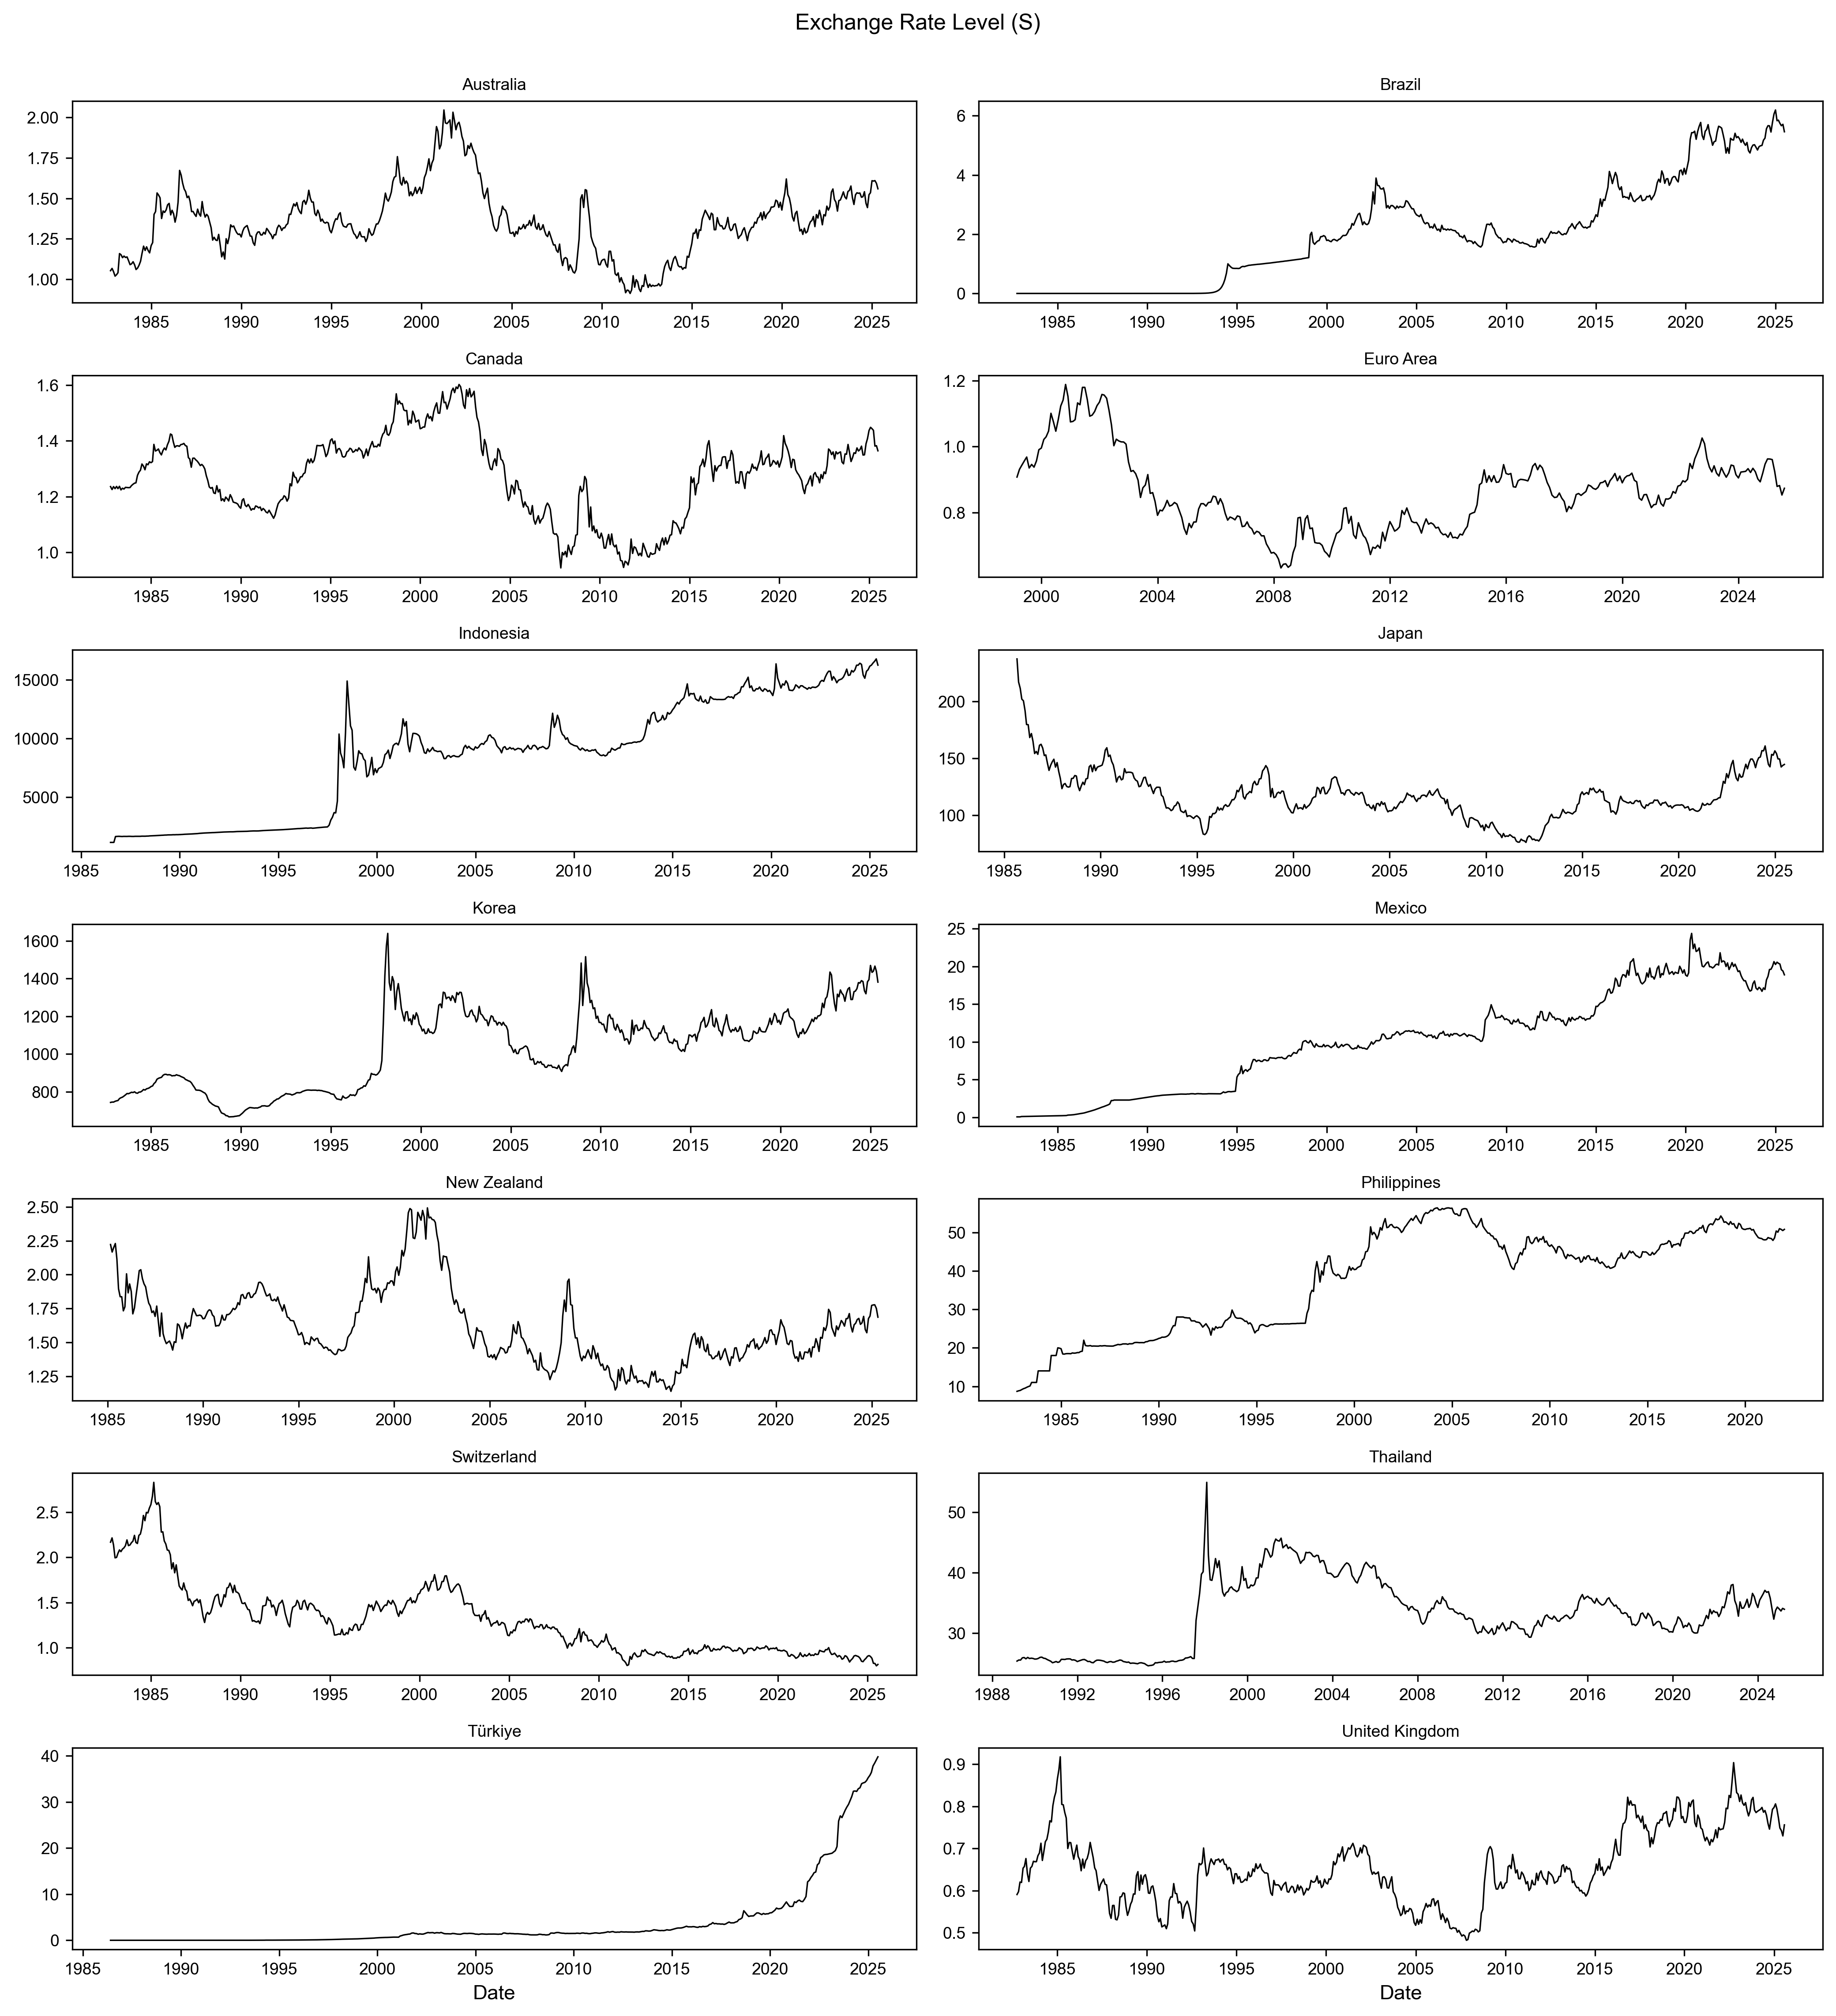

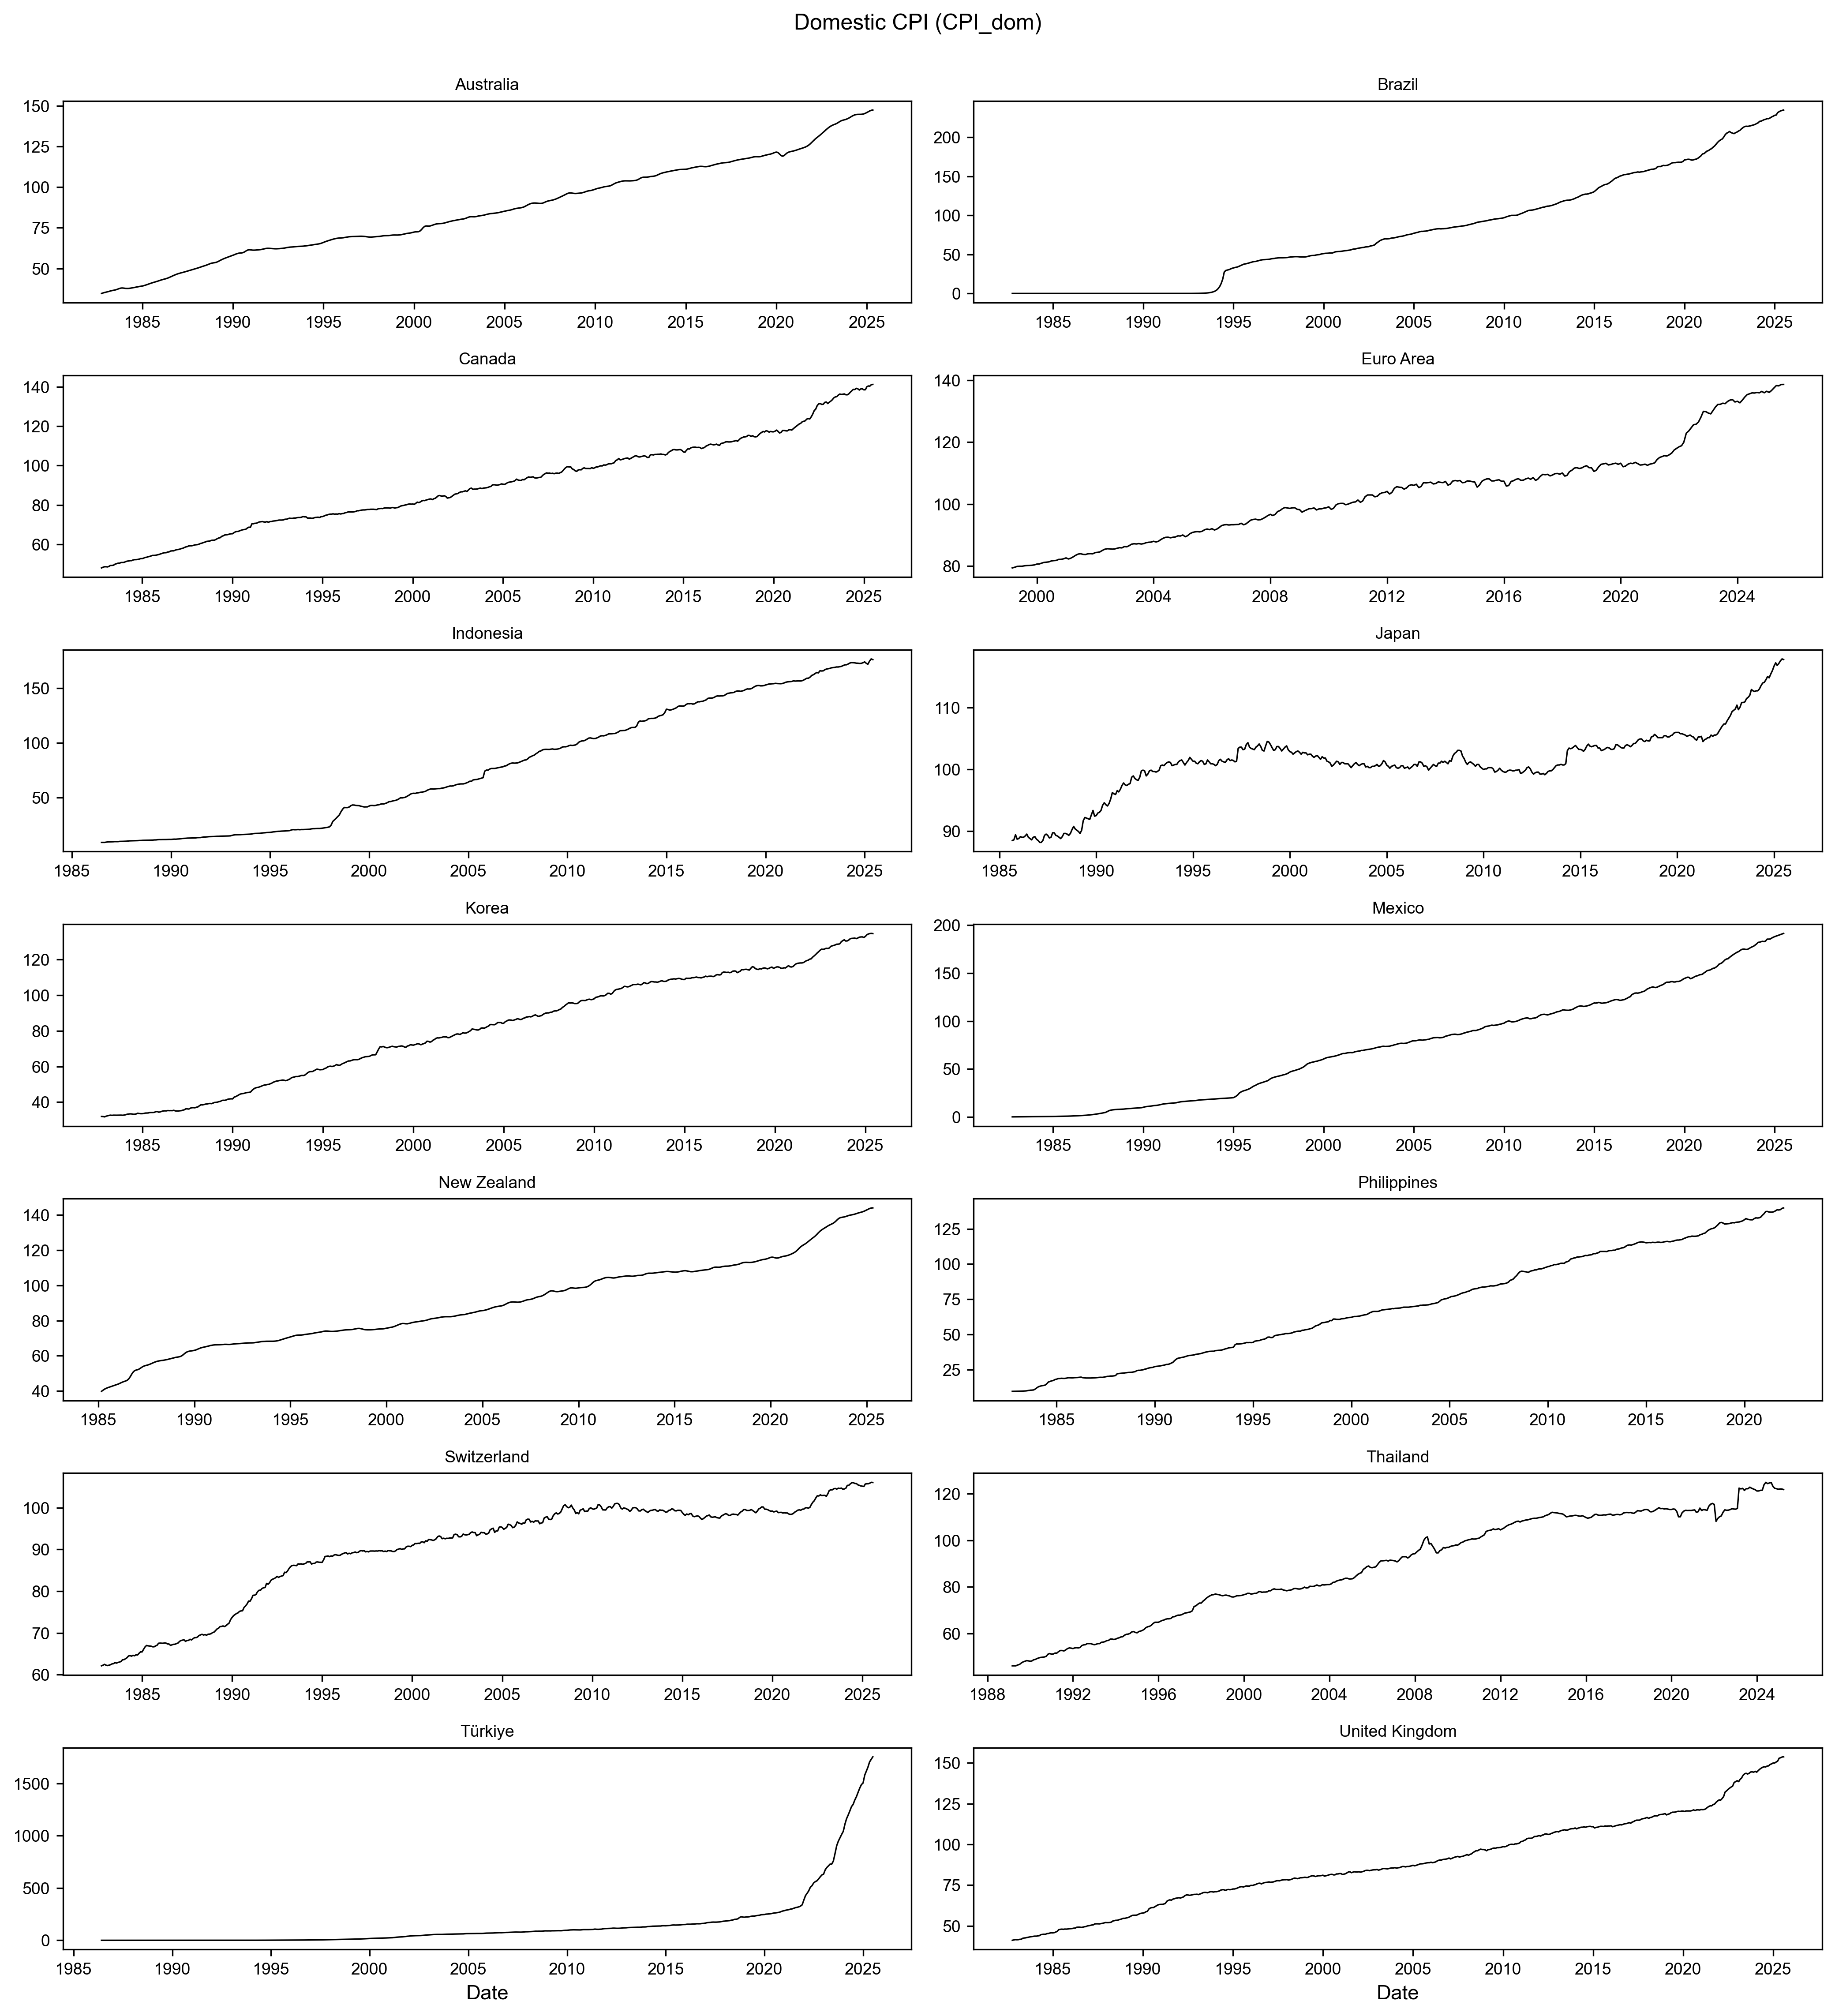

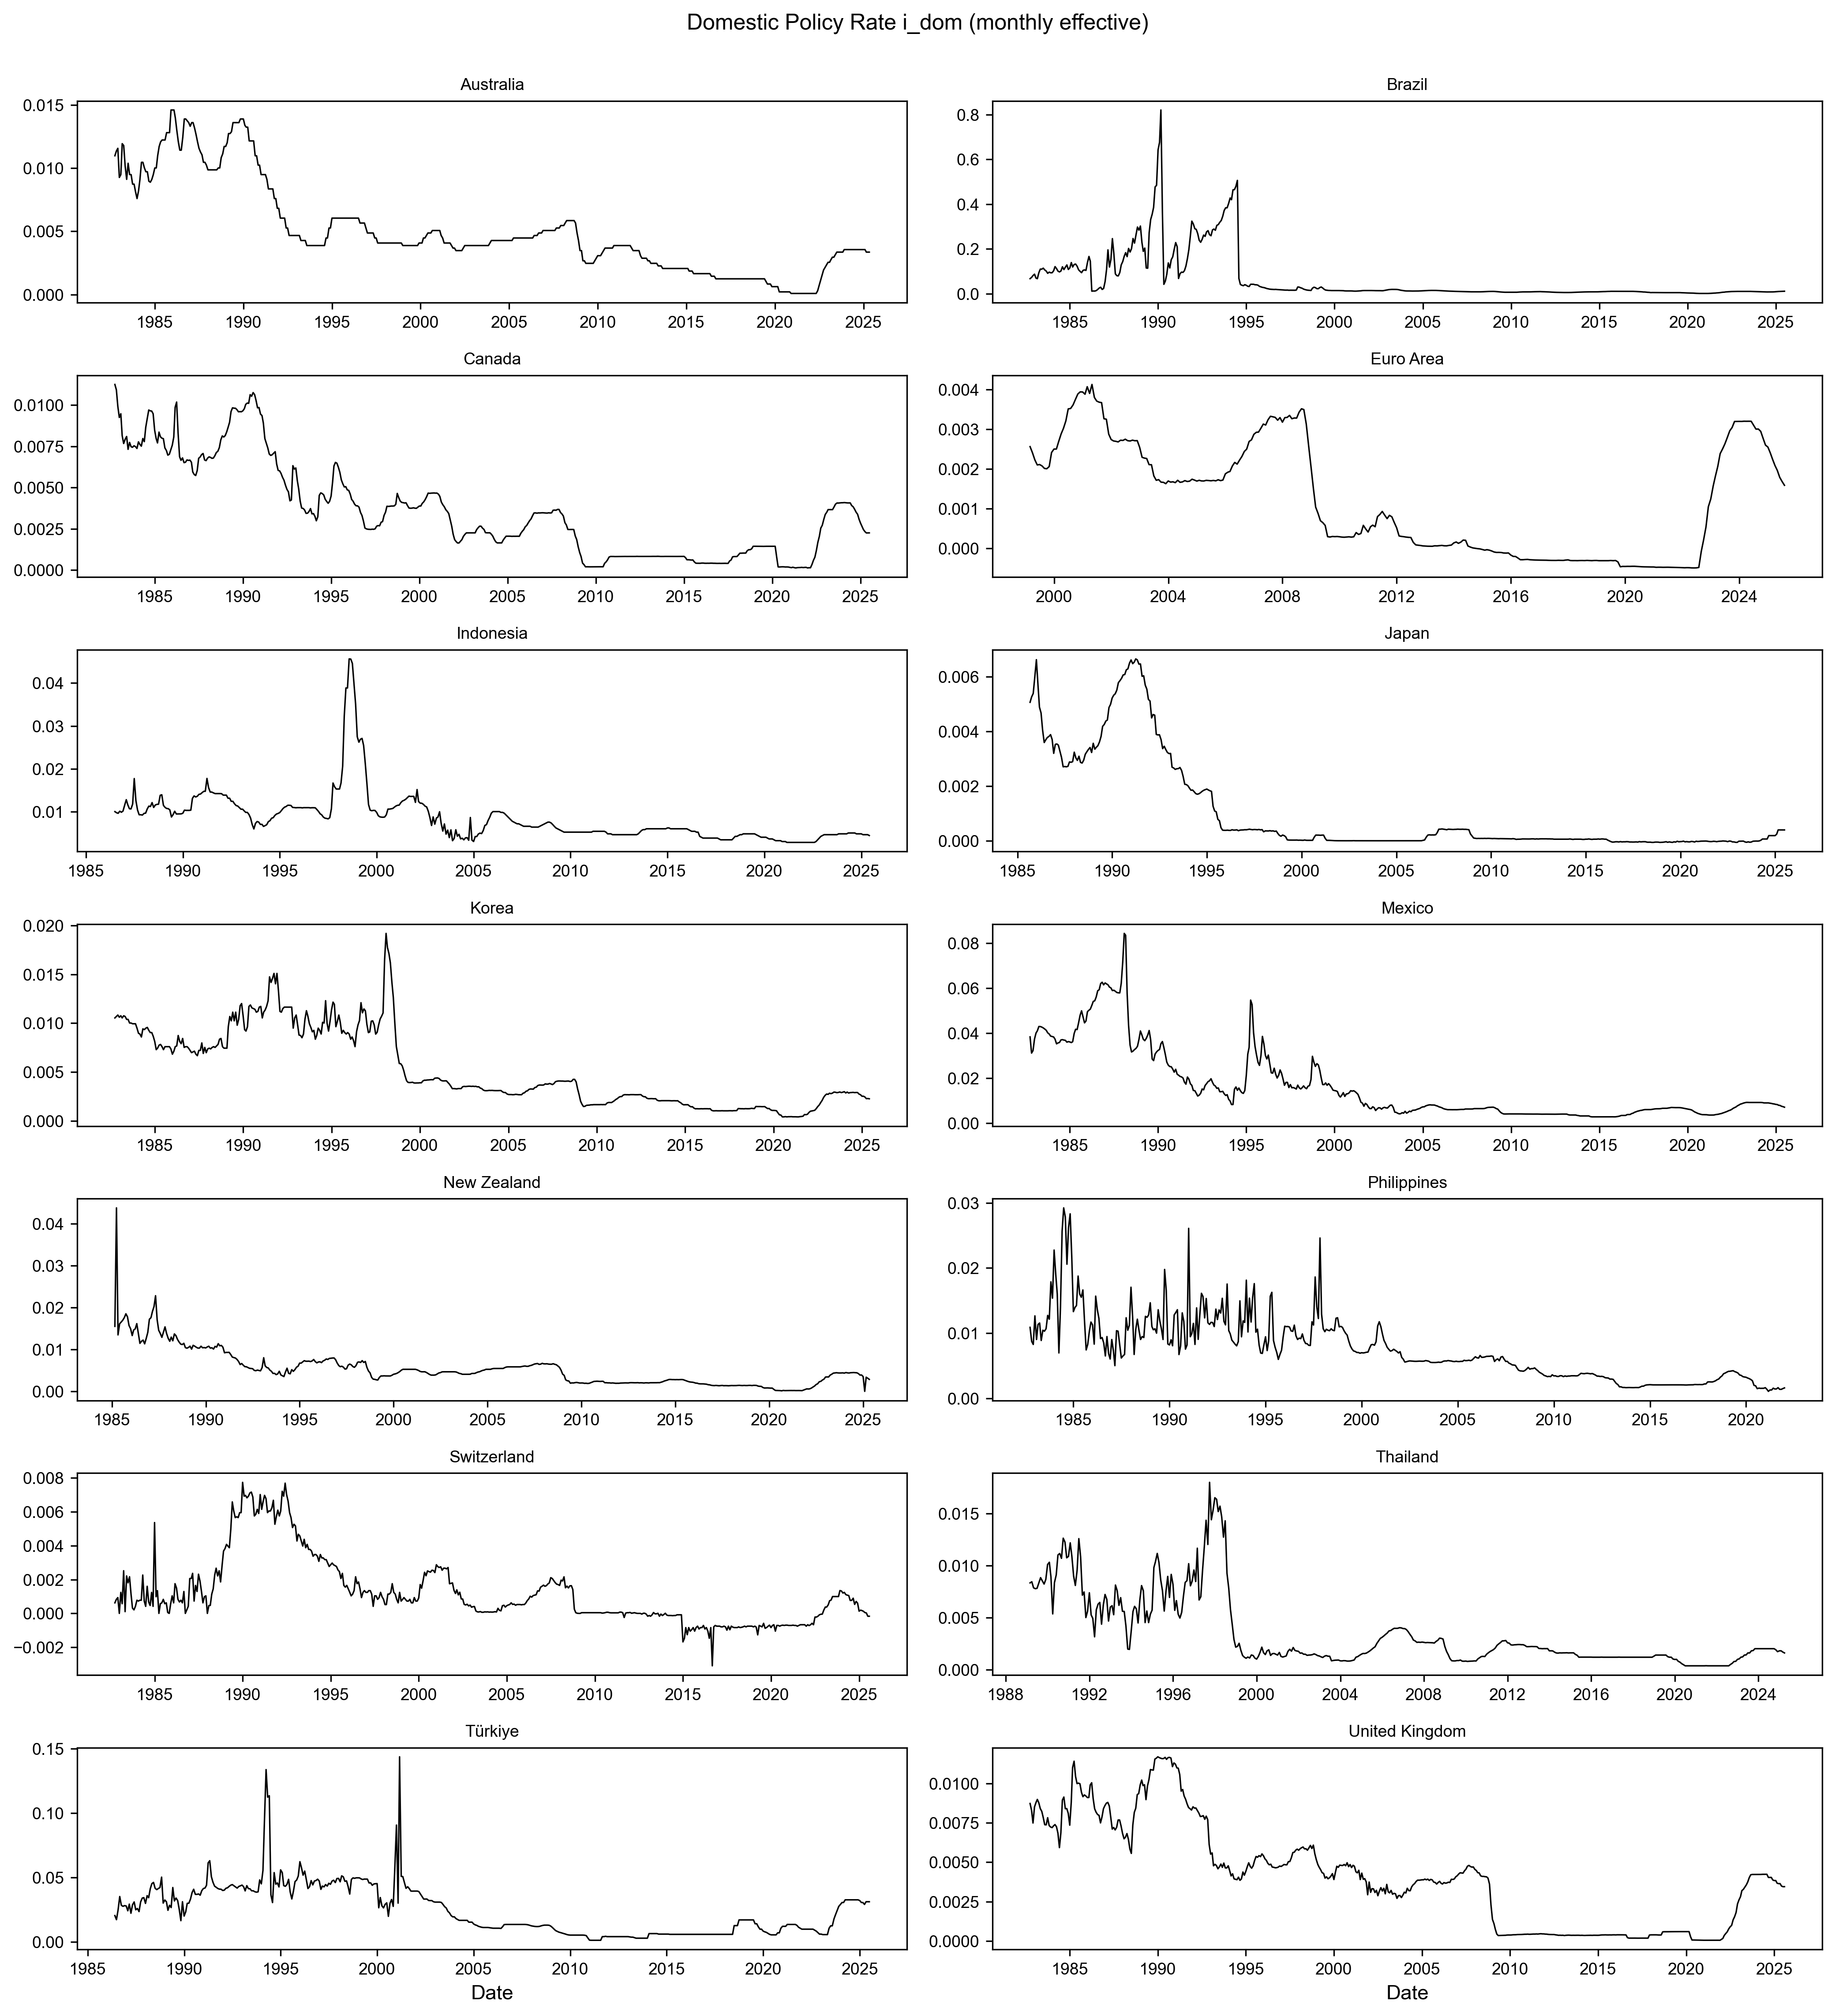

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Helper to create 7x2 subplot grid
COUNTRY_LIST = list(COUNTRIES.keys())
rows, cols = 7, 2

# 1) Exchange Rate S
fig, axes = plt.subplots(rows, cols, figsize=(14, 16), sharex=False)
axes = axes.flatten()
for i, country in enumerate(COUNTRY_LIST):
    sub = df_panel[df_panel['country'] == country].sort_values('date')
    axes[i].plot(sub['date'], sub['S'], color='black', linewidth=0.8)
    axes[i].set_title(country, fontsize=9)
    axes[i].grid(False)
for ax in axes[(rows-1)*cols:]:
    ax.set_xlabel('Date')
fig.suptitle('Exchange Rate Level (S)', fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
path_png = agg_fig_dir / 'raw_series_exchange_rate.png'
path_pdf = agg_fig_dir / 'raw_series_exchange_rate.pdf'
fig.savefig(path_png, dpi=300)
fig.savefig(path_pdf)
print(f"✓ Saved: {path_png.name}, {path_pdf.name}")

# 2) Domestic CPI
fig, axes = plt.subplots(rows, cols, figsize=(14, 16), sharex=False)
axes = axes.flatten()
for i, country in enumerate(COUNTRY_LIST):
    sub = df_panel[df_panel['country'] == country].sort_values('date')
    axes[i].plot(sub['date'], sub['CPI_dom'], color='black', linewidth=0.8)
    axes[i].set_title(country, fontsize=9)
    axes[i].grid(False)
for ax in axes[(rows-1)*cols:]:
    ax.set_xlabel('Date')
fig.suptitle('Domestic CPI (CPI_dom)', fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
path_png = agg_fig_dir / 'raw_series_cpi_dom.png'
path_pdf = agg_fig_dir / 'raw_series_cpi_dom.pdf'
fig.savefig(path_png, dpi=300)
fig.savefig(path_pdf)
print(f"✓ Saved: {path_png.name}, {path_pdf.name}")

# 3) Domestic Policy Rate (monthly effective)
fig, axes = plt.subplots(rows, cols, figsize=(14, 16), sharex=False)
axes = axes.flatten()
for i, country in enumerate(COUNTRY_LIST):
    sub = df_panel[df_panel['country'] == country].sort_values('date')
    axes[i].plot(sub['date'], sub['i_dom'], color='black', linewidth=0.8)
    axes[i].set_title(country, fontsize=9)
    axes[i].grid(False)
for ax in axes[(rows-1)*cols:]:
    ax.set_xlabel('Date')
fig.suptitle('Domestic Policy Rate i_dom (monthly effective)', fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
path_png = agg_fig_dir / 'raw_series_interest_dom.png'
path_pdf = agg_fig_dir / 'raw_series_interest_dom.pdf'
fig.savefig(path_png, dpi=300)
fig.savefig(path_pdf)
print(f"✓ Saved: {path_png.name}, {path_pdf.name}")

## 3. Model Estimation

Estimate STR and BUIP models for all countries.

**STR Model**: Smooth Transition Regression with automatic transition variable selection via linearity tests.

**BUIP Model**: Behavioral Uncovered Interest Parity with utility-based regime switching.

All estimation functions are in `src/analysis.py` for code organization.

In [43]:
"""
Estimate STR and BUIP models for all countries.

This will:
1. For STR: Test 35 transition variable candidates, select best via LM test, estimate via grid search + NLS
2. For BUIP: Estimate behavioral model with multistart optimization

Progress and results will be printed for each country.
"""

# Run estimation pipeline (defined in src/analysis.py)
str_results, buip_results = estimate_all_countries(df_panel, COUNTRIES, model_type='both')

print(f"\n{'='*60}")
print(f"ESTIMATION SUMMARY")
print(f"{'='*60}")
print(f"STR models successfully estimated: {len(str_results)} / {len(COUNTRIES)}")
print(f"BUIP models successfully estimated: {len(buip_results)} / {len(COUNTRIES)}")


Processing Australia
Running linearity tests for 35 candidates...
Best transition variable: drf_abs_lag3 (p=0.0042)
Running grid search...
Grid search complete. Starting NLS...

STR Results for Australia:
const      0.001535
beta_c     0.023527
beta_f     0.039274
gamma     56.880641
c          0.007129
const1     0.030227
dtype: float64
AIC: -3495.72, BIC: -3470.33

BUIP: Australia
Sample size: 509
Running multistart optimization...

BUIP Results for Australia:
beta_f      0.016591
beta_c      0.088594
gamma     149.766101
c           0.000108
const       0.006100
const1     -0.006999
dtype: float64
AIC: -3487.21, BIC: -3461.81

Processing Brazil
Running linearity tests for 35 candidates...
Best transition variable: eta_lag1 (p=0.0000)
Running grid search...
Grid search complete. Starting NLS...

STR Results for Brazil:
const     0.030003
beta_c    1.914609
beta_f    0.186862
gamma     2.517481
c         0.267417
const1    0.070814
dtype: float64
AIC: -2257.72, BIC: -2232.28

BUIP: B

## 4. Results Tables

Generate publication-ready tables with parameter estimates and significance stars.

### 4.1 Transition Variable Selection Table

Shows which transition variable was selected for each country based on the LM linearity test.

In [44]:
"""
Generate table showing the selected transition variable for each country.
The transition variable with the lowest p-value in the LM linearity test is selected.
"""
print("\n" + "="*60)
print("TRANSITION VARIABLE SELECTION TABLE")
print("="*60)

# Build table from STR results
tv_selection_rows = []
for country_name in COUNTRIES.keys():
    if country_name in str_results:
        result_dict = str_results[country_name]
        tv_selection_rows.append({
            'Country': country_name,
            'Transition Variable': result_dict['z_name'],
            'P-value': f"{result_dict['lm_pval']:.4f}"
        })
    else:
        tv_selection_rows.append({
            'Country': country_name,
            'Transition Variable': 'N/A',
            'P-value': 'N/A'
        })

df_tv_selection = pd.DataFrame(tv_selection_rows)
print("\n")
print(df_tv_selection.to_string(index=False))

# Save outputs
csv_path = tables_dir / 'transition_variable_selection.csv'
tex_path = tables_dir / 'transition_variable_selection.tex'

df_tv_selection.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path.name}")

# Create LaTeX version
with open(tex_path, 'w') as f:
    f.write(df_tv_selection.to_latex(
        index=False,
        escape=False,
        caption='Selected Transition Variables for STR Models (LM Linearity Test)',
        label='tab:transition_variables'
    ))
print(f"✓ Saved: {tex_path.name}")


TRANSITION VARIABLE SELECTION TABLE


       Country       Transition Variable P-value
     Australia              drf_abs_lag3  0.0042
        Brazil                  eta_lag1  0.0000
        Canada rel_misalignment_abs_lag2  0.0000
     Euro Area              ppp_abs_lag4  0.0001
     Indonesia              eta_abs_lag4  0.0000
         Japan rel_misalignment_abs_lag2  0.0035
         Korea rel_misalignment_abs_lag4  0.0000
        Mexico                  eta_lag1  0.0000
   New Zealand                   ID_lag4  0.0010
   Philippines                  eta_lag4  0.0013
   Switzerland              drf_abs_lag2  0.0000
      Thailand                   ID_lag5  0.0000
       Türkiye                   ID_lag3  0.0000
United Kingdom                  eta_lag5  0.0000

✓ Saved: transition_variable_selection.csv
✓ Saved: transition_variable_selection.tex


### 4.2 STR and BUIP Models Estimation Results

In [45]:
"""
Generate results tables for STR and BUIP models.
Estimates significant at 5% level are shown in bold.
"""

def format_with_stars(estimate, pval):
    """Format estimates with significance stars. Bold if p < 0.05."""
    if np.isnan(pval) or np.isnan(estimate):
        return ''
    val_str = f"{estimate:.4f}"
    if pval < 0.01:
        return f"\\textbf{{{val_str}}}***"
    if pval < 0.05:
        return f"\\textbf{{{val_str}}}**"
    if pval < 0.10:
        return f"{val_str}*"
    return val_str

# ============================================================================
# STR Results Table
# ============================================================================
print("\n" + "="*60)
print("GENERATING STR RESULTS TABLE")
print("="*60)

str_rows = []
for country_name in COUNTRIES.keys():
    if country_name in str_results:
        res = str_results[country_name]['result']
        row = {'Country': country_name}
        for param in ['const', 'const1', 'beta_c', 'beta_f', 'gamma', 'c']:
            est = res.params.get(param, np.nan)
            pval = res.pvals.get(param, np.nan)
            row[param] = format_with_stars(est, pval)
        str_rows.append(row)
    else:
        str_rows.append({
            'Country': country_name,
            'const': '', 'const1': '', 'beta_c': '', 'beta_f': '', 'gamma': '', 'c': ''
        })

df_str_table = pd.DataFrame(str_rows).set_index('Country')
print(df_str_table)

# Save outputs
str_csv = tables_dir / 'str_results_table.csv'
str_tex = tables_dir / 'str_results_table.tex'
df_str_table.to_csv(str_csv)
with open(str_tex, 'w') as f:
    f.write(df_str_table.to_latex(escape=False, caption='STR Model Estimates', label='tab:str_results'))

print(f"\n✓ Saved: {str_csv.name}")
print(f"✓ Saved: {str_tex.name}")

# ============================================================================
# BUIP Results Table
# ============================================================================
print("\n" + "="*60)
print("GENERATING BUIP RESULTS TABLE")
print("="*60)

buip_rows = []
for country_name in COUNTRIES.keys():
    if country_name in buip_results:
        res = buip_results[country_name]
        row = {'Country': country_name}
        for param in ['const', 'const1', 'beta_c', 'beta_f', 'gamma', 'c']:
            est = res.params.get(param, np.nan)
            pval = res.pvals.get(param, np.nan)
            row[param] = format_with_stars(est, pval)
        buip_rows.append(row)
    else:
        buip_rows.append({
            'Country': country_name,
            'const': '', 'const1': '', 'beta_c': '', 'beta_f': '', 'gamma': '', 'c': ''
        })

df_buip_table = pd.DataFrame(buip_rows).set_index('Country')
print(df_buip_table)

# Save outputs
buip_csv = tables_dir / 'buip_results_table.csv'
buip_tex = tables_dir / 'buip_results_table.tex'
df_buip_table.to_csv(buip_csv)
with open(buip_tex, 'w') as f:
    f.write(df_buip_table.to_latex(escape=False, caption='BUIP Model Estimates', label='tab:buip_results'))

print(f"\n✓ Saved: {buip_csv.name}")
print(f"✓ Saved: {buip_tex.name}")


GENERATING STR RESULTS TABLE
                              const               const1              beta_c  \
Country                                                                        
Australia                    0.0015   \textbf{0.0302}***              0.0235   
Brazil           \textbf{0.0300}***    \textbf{0.0708}**  \textbf{1.9146}***   
Canada                      -0.0002               0.0022   \textbf{0.1816}**   
Euro Area        \textbf{0.0205}***  \textbf{-0.0241}***             -0.2023   
Indonesia                    0.0046               0.0049   \textbf{1.9983}**   
Japan                       -0.0020              -0.0014  \textbf{0.2274}***   
Korea             \textbf{0.0035}**               0.0453              0.2684   
Mexico           \textbf{0.0185}***               0.0457  \textbf{0.2029}***   
New Zealand                  0.0012               0.0004             -0.2442   
Philippines       \textbf{0.0123}**              -0.0049  \textbf{0.5002}***   
Switzerlan

### 4.3 Diagnostic Tests

Residual diagnostic tests for both STR and BUIP models: Ljung-Box (autocorrelation), ARCH (heteroskedasticity), and Jarque-Bera (normality).

In [46]:
"""
Generate diagnostic test tables for STR and BUIP models.
Tests: Ljung-Box Q (autocorrelation), ARCH (heteroskedasticity), Jarque-Bera (normality).
"""

from src.diagnostics import run_full_diagnostics

def format_test_result(stat, pval):
    """Format test statistic with p-value. Bold if significant at 5% level."""
    if np.isnan(stat) or np.isnan(pval):
        return ''
    stat_str = f"{stat:.4f}"
    pval_str = f"({pval:.4f})"
    if pval < 0.05:
        return f"\\textbf{{{stat_str}}} {pval_str}"
    return f"{stat_str} {pval_str}"

# ============================================================================
# STR Diagnostic Tests Table
# ============================================================================
print("\n" + "="*60)
print("GENERATING STR DIAGNOSTIC TESTS TABLE")
print("="*60)

str_diag_rows = []
for country_name in COUNTRIES.keys():
    if country_name in str_results:
        res = str_results[country_name]['result']
        
        # Run diagnostic tests
        diagnostics = run_full_diagnostics(res.resid)
        
        row = {'Country': country_name}
        
        # Ljung-Box Test (Autocorrelation)
        if 'ljung_box' in diagnostics and 'error' not in diagnostics['ljung_box']:
            lb = diagnostics['ljung_box']
            row['Ljung-Box Q'] = format_test_result(lb['Q_stat'], lb['p_value'])
        else:
            row['Ljung-Box Q'] = ''
        
        # ARCH Test (Heteroskedasticity)
        if 'arch' in diagnostics and 'error' not in diagnostics['arch']:
            arch = diagnostics['arch']
            row['ARCH LM'] = format_test_result(arch['LM_stat'], arch['p_value'])
        else:
            row['ARCH LM'] = ''
        
        # Jarque-Bera Test (Normality)
        if 'jarque_bera' in diagnostics and 'error' not in diagnostics['jarque_bera']:
            jb = diagnostics['jarque_bera']
            row['Jarque-Bera'] = format_test_result(jb['JB_stat'], jb['p_value'])
        else:
            row['Jarque-Bera'] = ''
        
        str_diag_rows.append(row)
    else:
        str_diag_rows.append({
            'Country': country_name,
            'Ljung-Box Q': '',
            'ARCH LM': '',
            'Jarque-Bera': ''
        })

df_str_diag = pd.DataFrame(str_diag_rows).set_index('Country')
print(df_str_diag)

# Save outputs
str_diag_csv = tables_dir / 'str_diagnostics_table.csv'
str_diag_tex = tables_dir / 'str_diagnostics_table.tex'
df_str_diag.to_csv(str_diag_csv)
with open(str_diag_tex, 'w') as f:
    f.write(df_str_diag.to_latex(escape=False, 
                                  caption='STR Model Diagnostic Tests (Test Statistic and p-value)', 
                                  label='tab:str_diagnostics'))

print(f"\n✓ Saved: {str_diag_csv.name}")
print(f"✓ Saved: {str_diag_tex.name}")

# ============================================================================
# BUIP Diagnostic Tests Table
# ============================================================================
print("\n" + "="*60)
print("GENERATING BUIP DIAGNOSTIC TESTS TABLE")
print("="*60)

buip_diag_rows = []
for country_name in COUNTRIES.keys():
    if country_name in buip_results:
        res = buip_results[country_name]
        
        # Run diagnostic tests
        diagnostics = run_full_diagnostics(res.resid)
        
        row = {'Country': country_name}
        
        # Ljung-Box Test (Autocorrelation)
        if 'ljung_box' in diagnostics and 'error' not in diagnostics['ljung_box']:
            lb = diagnostics['ljung_box']
            row['Ljung-Box Q'] = format_test_result(lb['Q_stat'], lb['p_value'])
        else:
            row['Ljung-Box Q'] = ''
        
        # ARCH Test (Heteroskedasticity)
        if 'arch' in diagnostics and 'error' not in diagnostics['arch']:
            arch = diagnostics['arch']
            row['ARCH LM'] = format_test_result(arch['LM_stat'], arch['p_value'])
        else:
            row['ARCH LM'] = ''
        
        # Jarque-Bera Test (Normality)
        if 'jarque_bera' in diagnostics and 'error' not in diagnostics['jarque_bera']:
            jb = diagnostics['jarque_bera']
            row['Jarque-Bera'] = format_test_result(jb['JB_stat'], jb['p_value'])
        else:
            row['Jarque-Bera'] = ''
        
        buip_diag_rows.append(row)
    else:
        buip_diag_rows.append({
            'Country': country_name,
            'Ljung-Box Q': '',
            'ARCH LM': '',
            'Jarque-Bera': ''
        })

df_buip_diag = pd.DataFrame(buip_diag_rows).set_index('Country')
print(df_buip_diag)

# Save outputs
buip_diag_csv = tables_dir / 'buip_diagnostics_table.csv'
buip_diag_tex = tables_dir / 'buip_diagnostics_table.tex'
df_buip_diag.to_csv(buip_diag_csv)
with open(buip_diag_tex, 'w') as f:
    f.write(df_buip_diag.to_latex(escape=False, 
                                   caption='BUIP Model Diagnostic Tests (Test Statistic and p-value)', 
                                   label='tab:buip_diagnostics'))

print(f"\n✓ Saved: {buip_diag_csv.name}")
print(f"✓ Saved: {buip_diag_tex.name}")


GENERATING STR DIAGNOSTIC TESTS TABLE
                              Ljung-Box Q                     ARCH LM  \
Country                                                                 
Australia                 9.0291 (0.5293)   \textbf{21.2761} (0.0003)   
Brazil          \textbf{85.4100} (0.0000)   \textbf{60.1330} (0.0000)   
Canada          \textbf{23.4180} (0.0093)   \textbf{15.2635} (0.0042)   
Euro Area                 7.5962 (0.6682)   \textbf{30.3847} (0.0000)   
Indonesia       \textbf{39.3933} (0.0000)  \textbf{128.9631} (0.0000)   
Japan           \textbf{20.2005} (0.0274)             5.3141 (0.2566)   
Korea           \textbf{38.7903} (0.0000)  \textbf{162.5249} (0.0000)   
Mexico          \textbf{86.9357} (0.0000)             4.3225 (0.3641)   
New Zealand     \textbf{20.5664} (0.0243)   \textbf{31.7558} (0.0000)   
Philippines     \textbf{38.2344} (0.0000)             8.4777 (0.0756)   
Switzerland              10.3420 (0.4110)             6.0242 (0.1973)   
Thailand    

### 4.4 Aggregate figures

In [47]:
"""
Generate aggregate figures across all countries:
- Regime distribution histograms
- Regime prevalence comparisons
"""
print("\n" + "="*60)
print("GENERATING AGGREGATE FIGURES")
print("="*60)

# ============================================================================
# STR Regime Distribution
# ============================================================================
all_G_values = []
for country_name, result_dict in str_results.items():
    G = result_dict['result'].G.dropna()
    all_G_values.extend(G.values)

if all_G_values:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(all_G_values, bins=50, color='black', edgecolor='black', linewidth=0.8)
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Transition Function G(z)')
    ax.set_ylabel('Frequency')
    ax.set_title('STR Regime Distribution')
    plt.tight_layout()
    
    fig_path_pdf = agg_fig_dir / 'str_regime_distribution.pdf'
    fig_path_png = agg_fig_dir / 'str_regime_distribution.png'
    plt.savefig(fig_path_pdf, bbox_inches='tight')
    plt.savefig(fig_path_png, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved: {fig_path_pdf.name}")

# ============================================================================
# BUIP Regime Distribution
# ============================================================================
all_omega_values = []
for country_name, result in buip_results.items():
    omega = result.omega.dropna()
    all_omega_values.extend(omega.values)

if all_omega_values:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(all_omega_values, bins=50, color='black', edgecolor='black', linewidth=0.8)
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Mixing Weight ω')
    ax.set_ylabel('Frequency')
    ax.set_title('BUIP Regime Distribution')
    plt.tight_layout()
    
    fig_path_pdf = agg_fig_dir / 'buip_regime_distribution.pdf'
    fig_path_png = agg_fig_dir / 'buip_regime_distribution.png'
    plt.savefig(fig_path_pdf, bbox_inches='tight')
    plt.savefig(fig_path_png, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved: {fig_path_pdf.name}")

# ============================================================================
# Regime Prevalence Comparison (STR vs BUIP)
# ============================================================================
str_chartist_pct = (np.array(all_G_values) > 0.5).mean() * 100 if all_G_values else 0
str_fund_pct = 100 - str_chartist_pct
buip_chartist_pct = (np.array(all_omega_values) < 0.5).mean() * 100 if all_omega_values else 0
buip_fund_pct = 100 - buip_chartist_pct

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, model, chartist, fund in [
    (axes[0], 'STR', str_chartist_pct, str_fund_pct),
    (axes[1], 'BUIP', buip_chartist_pct, buip_fund_pct)
]:
    ax.bar(['Chartist', 'Fundamentalist'], [chartist, fund], 
           color='black', edgecolor='black', linewidth=0.9)
    ax.set_title(f'{model} Regime Prevalence')
    ax.set_ylim(0, 100)
    ax.set_ylabel('Prevalence (%)') if ax is axes[0] else None

plt.tight_layout()
fig_path_pdf = agg_fig_dir / 'regime_prevalence_comparison.pdf'
fig_path_png = agg_fig_dir / 'regime_prevalence_comparison.png'
plt.savefig(fig_path_pdf, bbox_inches='tight')
plt.savefig(fig_path_png, dpi=300, bbox_inches='tight')
plt.close(fig)
print(f"✓ Saved: {fig_path_pdf.name}")


GENERATING AGGREGATE FIGURES
✓ Saved: str_regime_distribution.pdf
✓ Saved: buip_regime_distribution.pdf
✓ Saved: regime_prevalence_comparison.pdf


### 4.4.1 Regime Distribution and Prevalence by Group

Side-by-side comparison for Complete sample, Advanced, and Emergent countries (1x3 grid).

✓ Saved: str_regime_distribution_groups.png, str_regime_distribution_groups.pdf
✓ Saved: str_regime_prevalence_groups.png, str_regime_prevalence_groups.pdf
✓ Saved: str_regime_prevalence_groups.png, str_regime_prevalence_groups.pdf
✓ Saved: buip_regime_distribution_groups.png, buip_regime_distribution_groups.pdf
✓ Saved: buip_regime_distribution_groups.png, buip_regime_distribution_groups.pdf
✓ Saved: buip_regime_prevalence_groups.png, buip_regime_prevalence_groups.pdf
✓ Saved: buip_regime_prevalence_groups.png, buip_regime_prevalence_groups.pdf


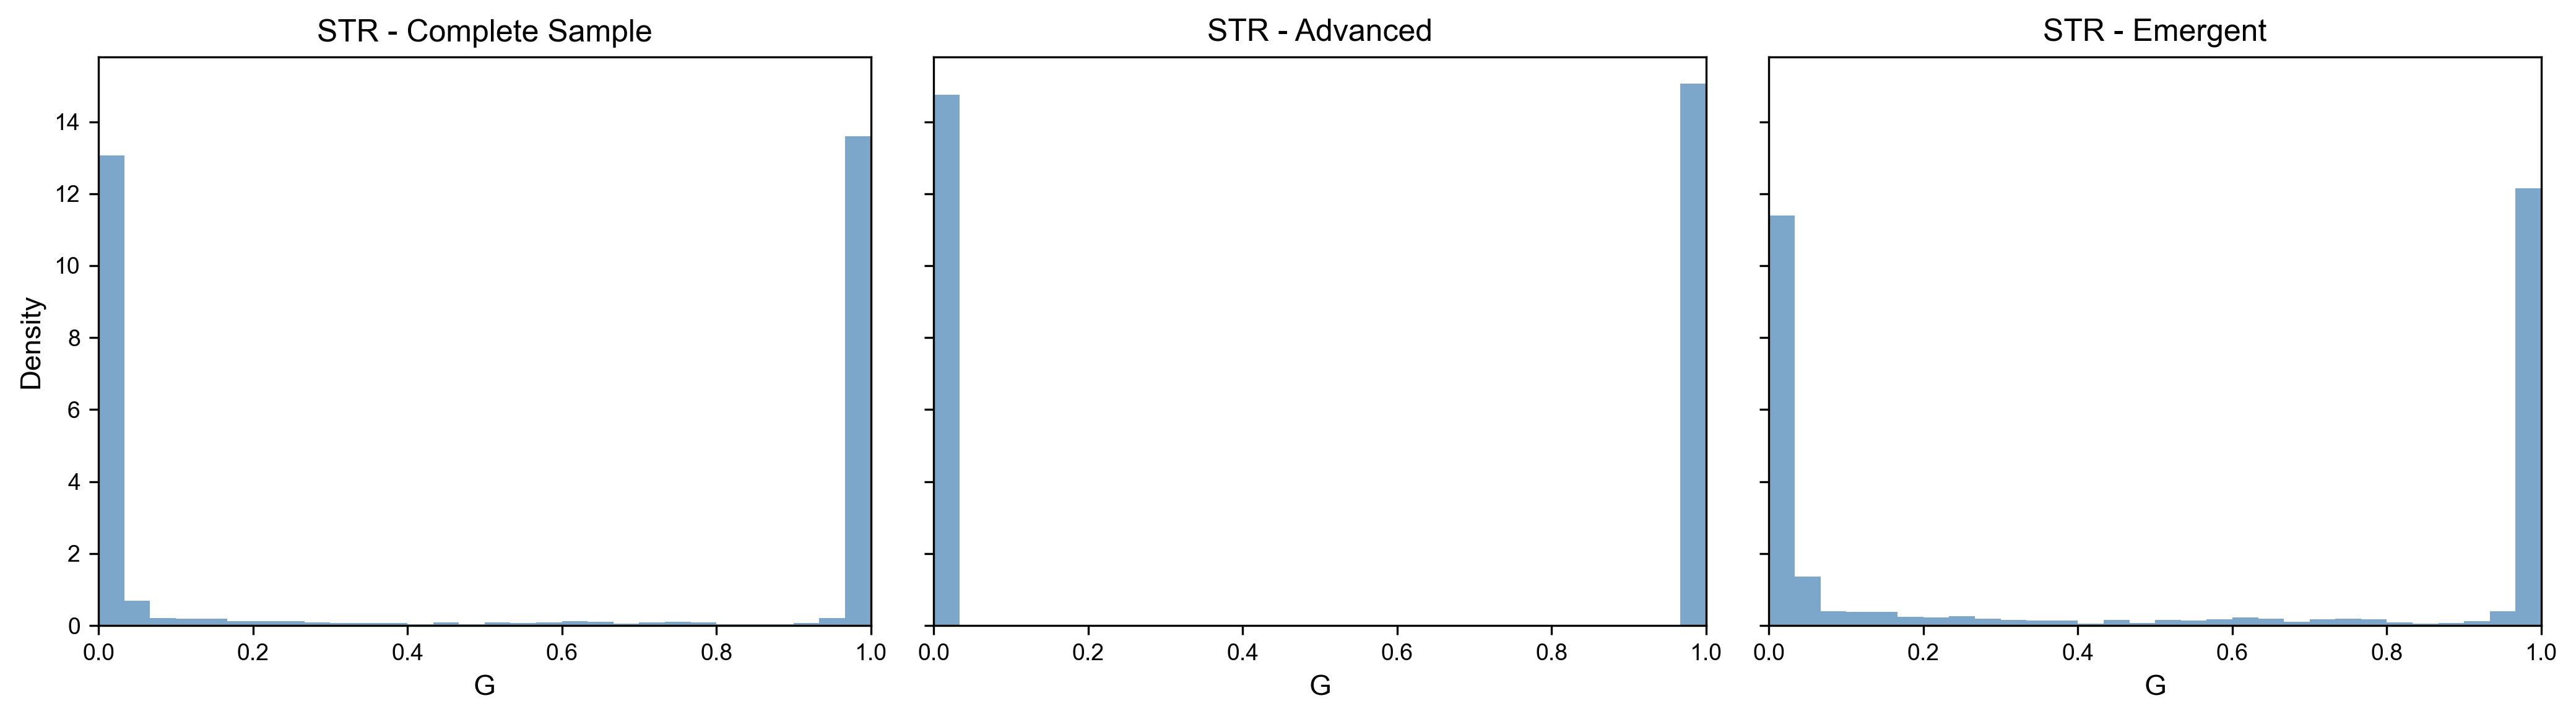

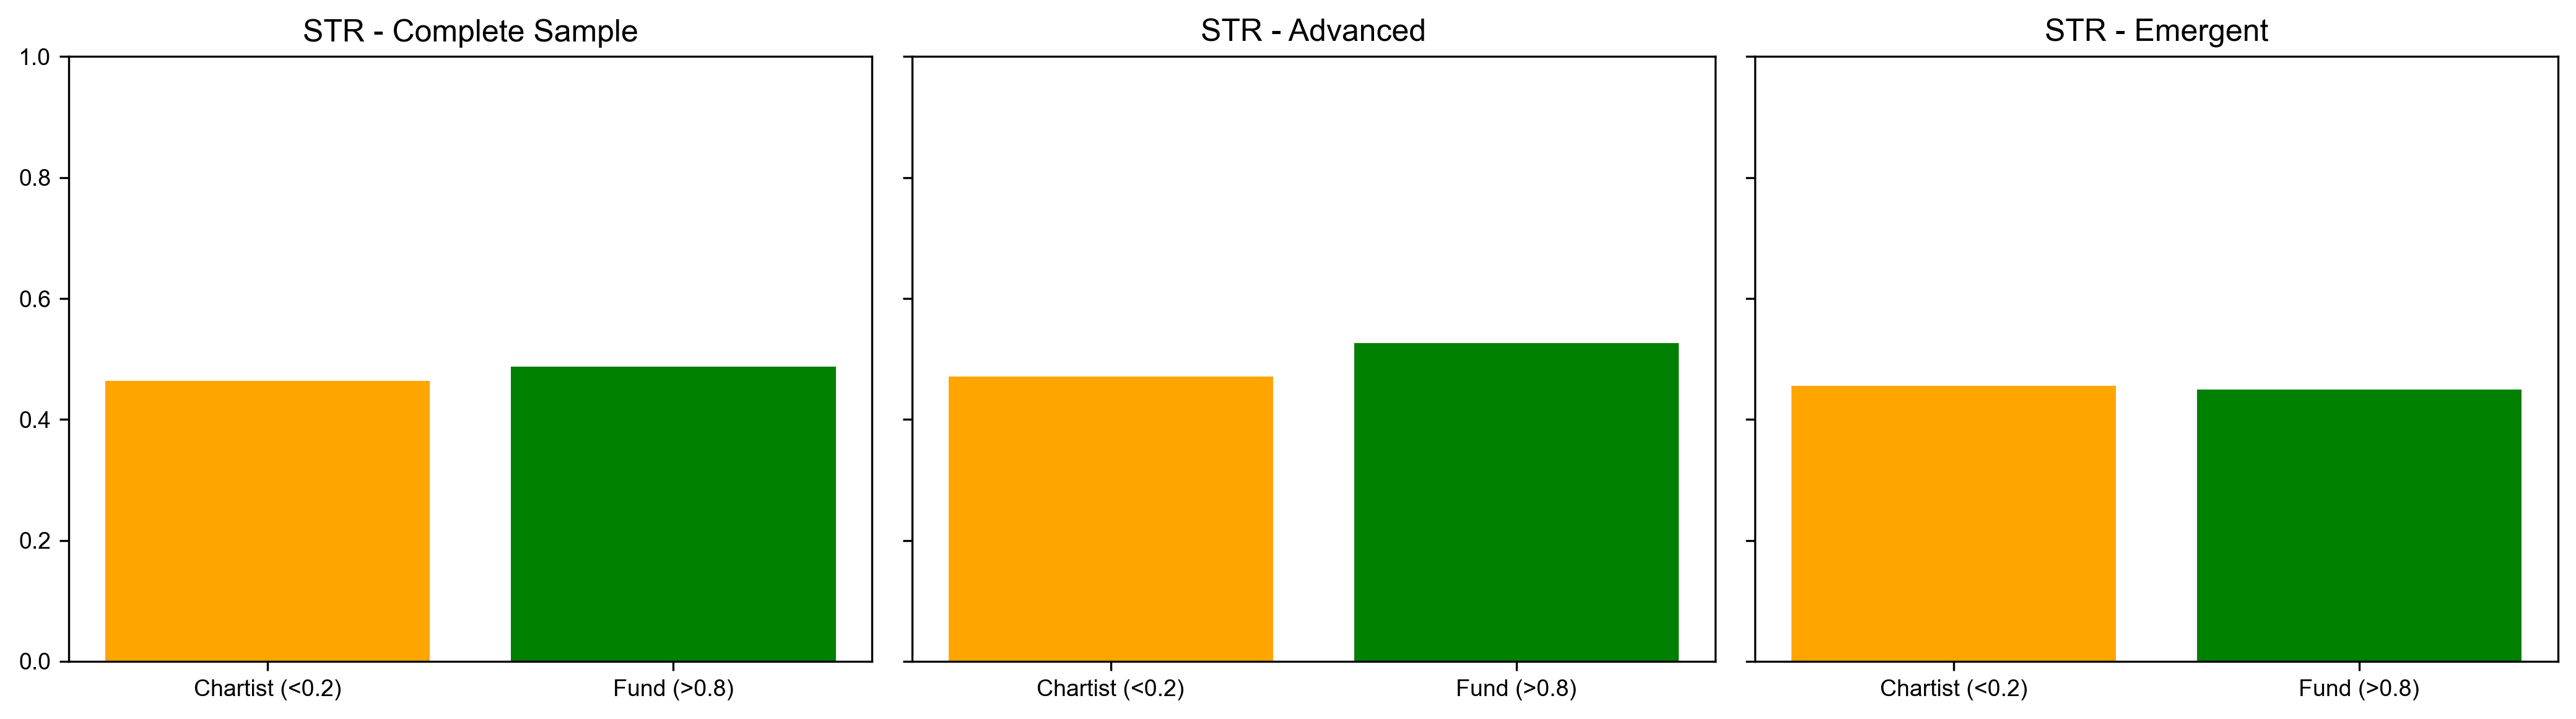

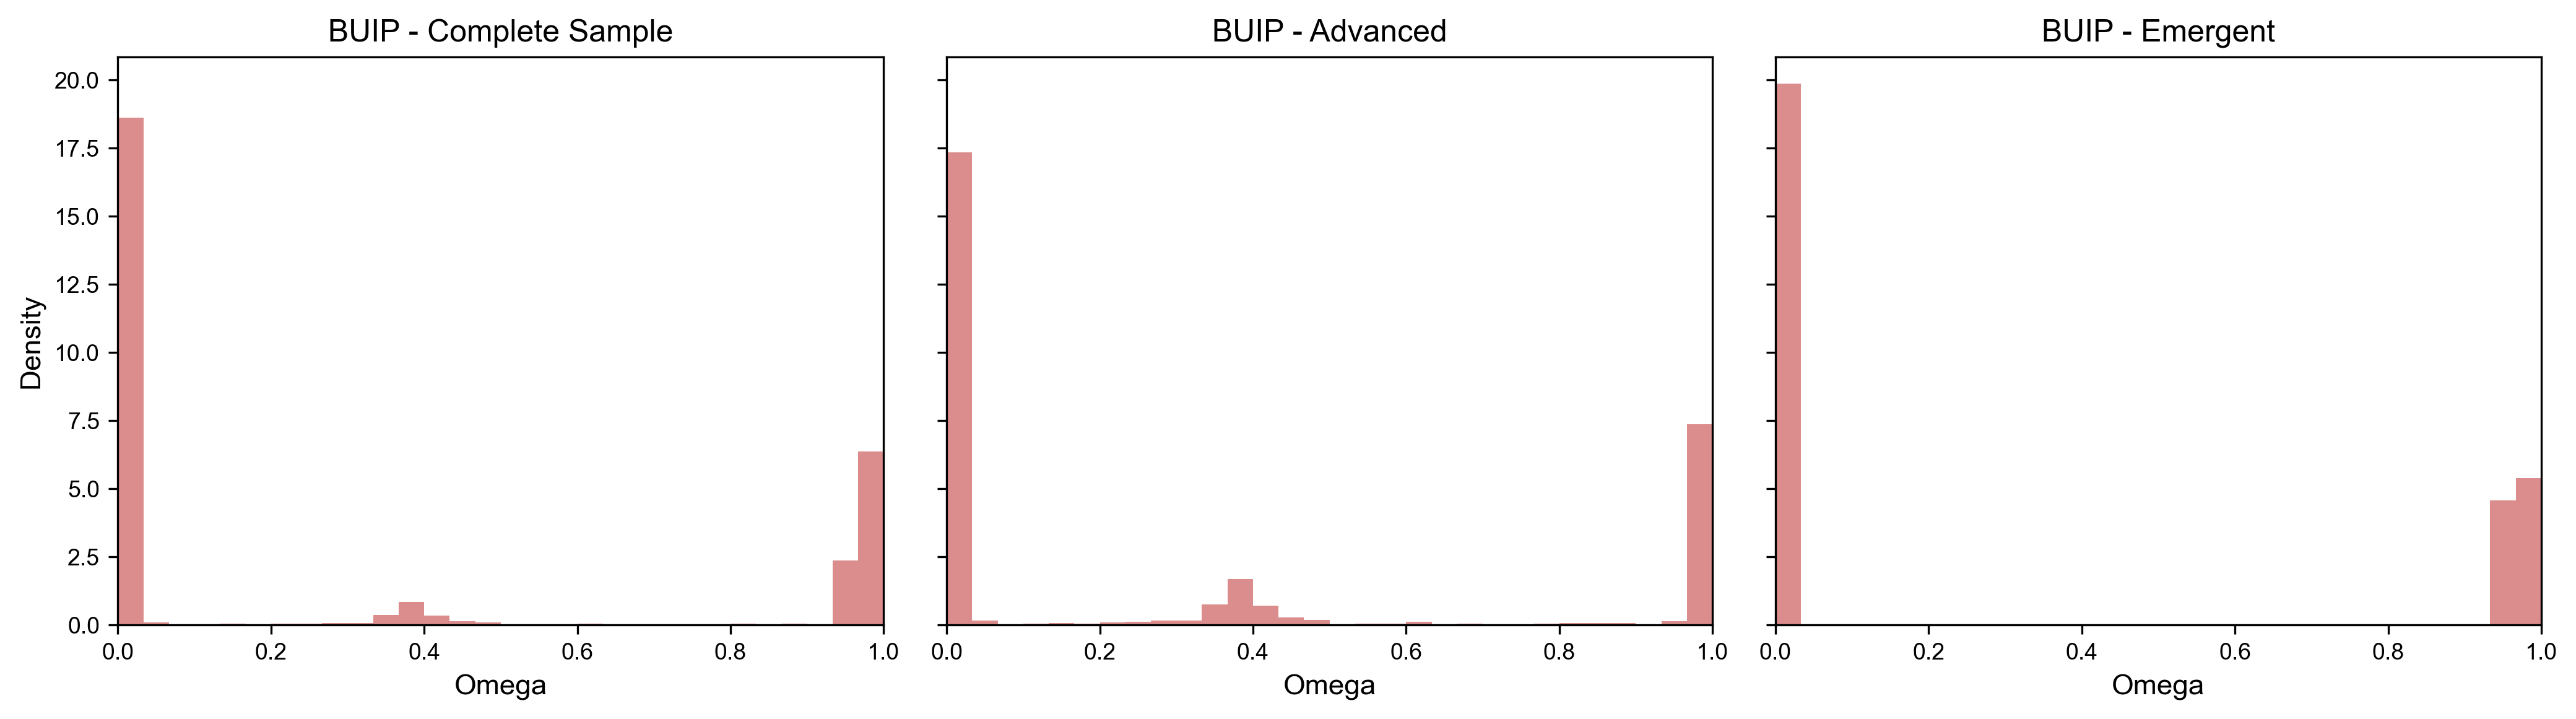

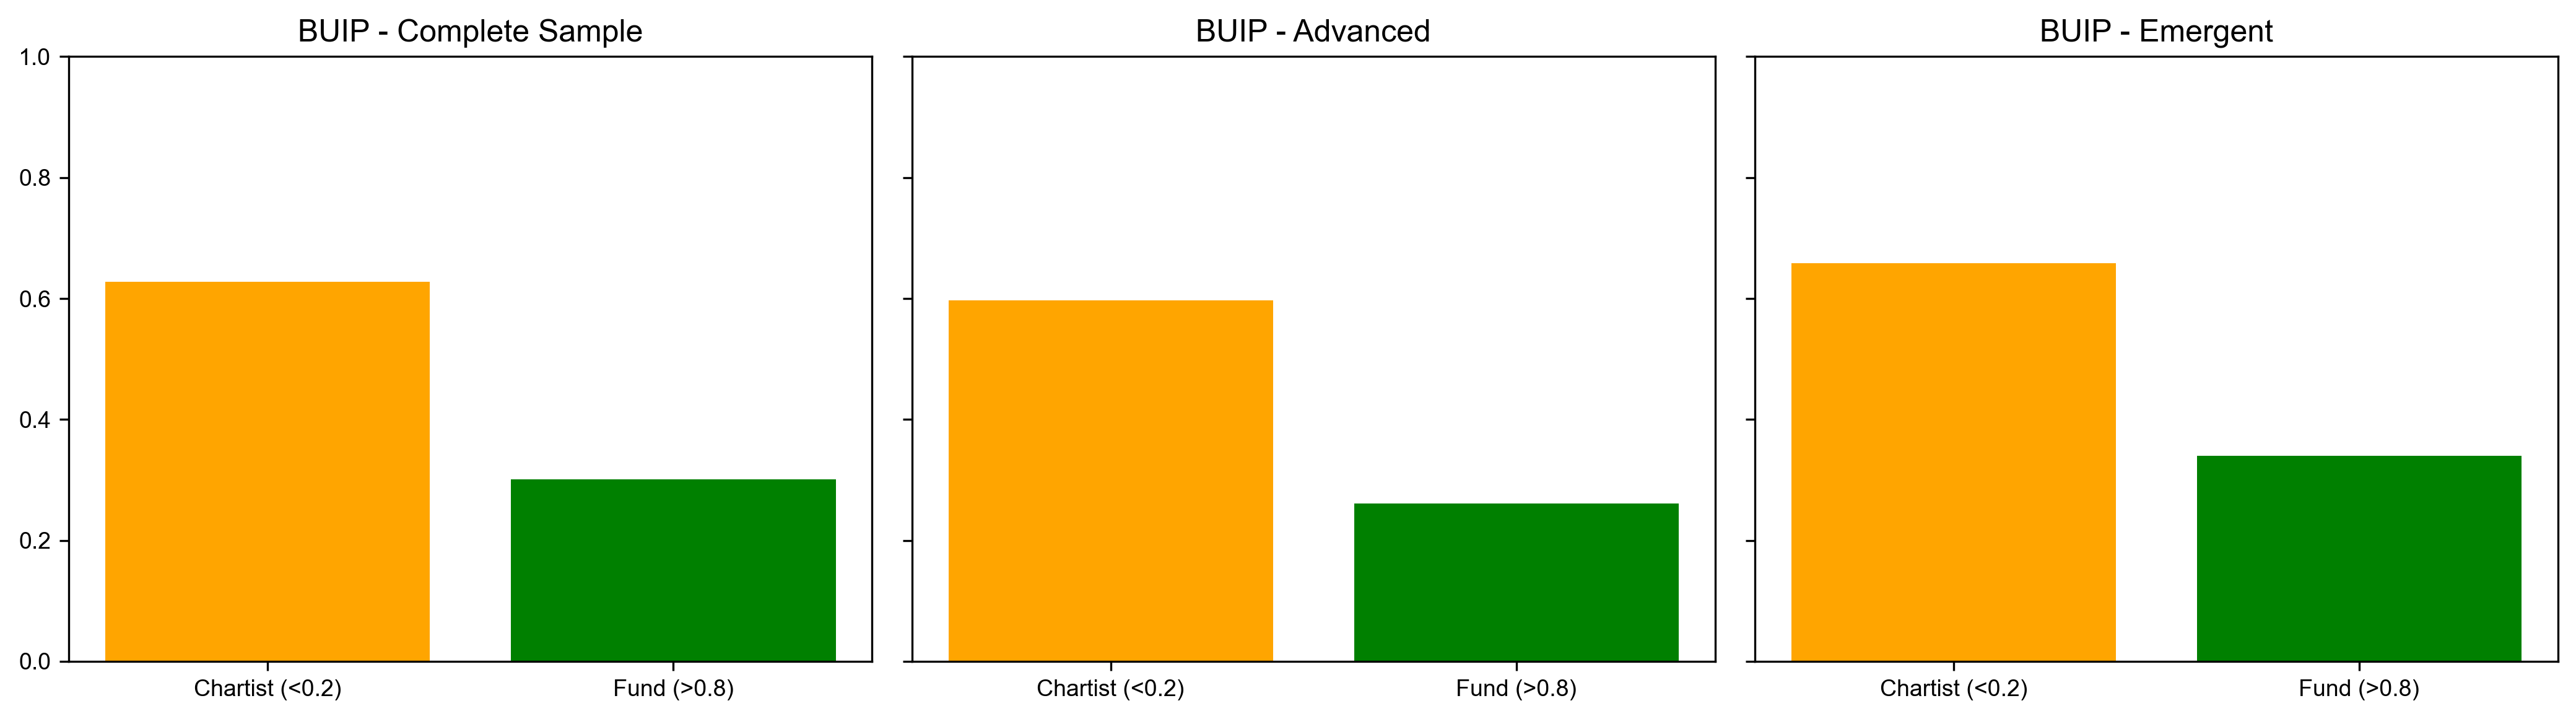

In [49]:
# Define Advanced and Emergent groups (adjust as needed)
ADVANCED = {
    'Australia','Canada','Euro Area','Japan','New Zealand','Switzerland','United Kingdom'
}
EMERGENT = set(COUNTRIES.keys()) - ADVANCED

# Helper to compute regime distribution and prevalence
import matplotlib.pyplot as plt
import numpy as np

def regime_stats_for_group(results_dict, group_names, model_label):
    """
    Compute regime statistics for a group of countries.
    
    Handles both data structures:
    - STR results: {country: {'result': StrResult, 'z_name': str}}
    - BUIP results: {country: BuipResult}
    """
    G_vals = []
    chartist_pct = []
    fund_pct = []
    for c in group_names:
        if c in results_dict:
            entry = results_dict[c]
            # Handle STR structure: {'result': StrResult, 'z_name': ...}
            if isinstance(entry, dict) and 'result' in entry:
                res = entry['result']
            else:
                res = entry
            # Get G (STR) or omega (BUIP)
            if hasattr(res, 'G'):
                G = res.G
            elif hasattr(res, 'omega'):
                G = res.omega
            else:
                continue
            G_vals.append(G.dropna())
            chartist_pct.append(float((G < 0.2).mean()))
            fund_pct.append(float((G > 0.8).mean()))
    G_all = pd.concat(G_vals) if len(G_vals) else pd.Series([], dtype=float)
    return {
        'G_all': G_all,
        'chartist_mean': float(np.mean(chartist_pct)) if chartist_pct else np.nan,
        'fund_mean': float(np.mean(fund_pct)) if fund_pct else np.nan,
        'label': model_label
    }

# Plot regime distributions (1x3) for STR
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for i, (title, names) in enumerate([
    ("Complete Sample", COUNTRIES.keys()),
    ("Advanced", ADVANCED),
    ("Emergent", EMERGENT)
]):
    stats = regime_stats_for_group(str_results, names, 'STR')
    axes[i].hist(stats['G_all'], bins=30, density=True, color='steelblue', alpha=0.7)
    axes[i].set_title(f"STR - {title}")
    axes[i].set_xlabel("G")
    axes[i].set_xlim(0,1)
axes[0].set_ylabel("Density")
plt.tight_layout()

# Save STR histogram grid
path_png = agg_fig_dir / 'str_regime_distribution_groups.png'
path_pdf = agg_fig_dir / 'str_regime_distribution_groups.pdf'
fig.savefig(path_png, dpi=300)
fig.savefig(path_pdf)
print(f"✓ Saved: {path_png.name}, {path_pdf.name}")

# Plot regime prevalence comparisons (1x3) for STR
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for i, (title, names) in enumerate([
    ("Complete Sample", COUNTRIES.keys()),
    ("Advanced", ADVANCED),
    ("Emergent", EMERGENT)
]):
    stats = regime_stats_for_group(str_results, names, 'STR')
    axes[i].bar(["Chartist (<0.2)", "Fund (>0.8)"], [stats['chartist_mean'], stats['fund_mean']], color=['orange','green'])
    axes[i].set_title(f"STR - {title}")
    axes[i].set_ylim(0,1)
plt.tight_layout()

# Save STR prevalence grid
path_png = agg_fig_dir / 'str_regime_prevalence_groups.png'
path_pdf = agg_fig_dir / 'str_regime_prevalence_groups.pdf'
fig.savefig(path_png, dpi=300)
fig.savefig(path_pdf)
print(f"✓ Saved: {path_png.name}, {path_pdf.name}")

# Repeat for BUIP
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for i, (title, names) in enumerate([
    ("Complete Sample", COUNTRIES.keys()),
    ("Advanced", ADVANCED),
    ("Emergent", EMERGENT)
]):
    stats = regime_stats_for_group(buip_results, names, 'BUIP')
    axes[i].hist(stats['G_all'], bins=30, density=True, color='indianred', alpha=0.7)
    axes[i].set_title(f"BUIP - {title}")
    axes[i].set_xlabel("Omega")
    axes[i].set_xlim(0,1)
axes[0].set_ylabel("Density")
plt.tight_layout()

# Save BUIP histogram grid
path_png = agg_fig_dir / 'buip_regime_distribution_groups.png'
path_pdf = agg_fig_dir / 'buip_regime_distribution_groups.pdf'
fig.savefig(path_png, dpi=300)
fig.savefig(path_pdf)
print(f"✓ Saved: {path_png.name}, {path_pdf.name}")

# BUIP prevalence grid
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for i, (title, names) in enumerate([
    ("Complete Sample", COUNTRIES.keys()),
    ("Advanced", ADVANCED),
    ("Emergent", EMERGENT)
]):
    stats = regime_stats_for_group(buip_results, names, 'BUIP')
    axes[i].bar(["Chartist (<0.2)", "Fund (>0.8)"], [stats['chartist_mean'], stats['fund_mean']], color=['orange','green'])
    axes[i].set_title(f"BUIP - {title}")
    axes[i].set_ylim(0,1)
plt.tight_layout()

path_png = agg_fig_dir / 'buip_regime_prevalence_groups.png'
path_pdf = agg_fig_dir / 'buip_regime_prevalence_groups.pdf'
fig.savefig(path_png, dpi=300)
fig.savefig(path_pdf)
print(f"✓ Saved: {path_png.name}, {path_pdf.name}")

## 5. Detailed Country Plots

Generate detailed diagnostic plots for each country showing transition functions and regime evolution.

In [ ]:
"""
Generate detailed country-specific plots for STR and BUIP models.
Each plot shows the transition variable, transition function, and regime evolution.
"""
import importlib
import src.output_figures
importlib.reload(src.output_figures)
from src.output_figures import plot_country_detailed_analysis
from src.utils import build_beh_sample

print("\n" + "="*60)
print("GENERATING DETAILED COUNTRY PLOTS")
print("="*60)

# ============================================================================
# STR Detailed Plots
# ============================================================================
print("\nSTR plots:")
for country_name in str_results.keys():
    try:
        result_dict = str_results[country_name]
        str_result = result_dict['result']
        z_name = result_dict['z_name']
        
        # Get country data and transition variable
        country_df = df_panel[df_panel['country'] == country_name].copy().set_index('date').sort_index()
        z_candidates = build_z_candidates(country_df)
        z_series = z_candidates[z_name]
        y = country_df['r_s'] - (country_df['i_for'] - country_df['i_dom'])
        
        # Generate and save plot
        save_path = country_fig_dir / f"{country_name.replace(' ', '_')}_str_detailed.pdf"
        plot_country_detailed_analysis(
            y=y,
            transition_var=z_series,
            transition_func=str_result.G,
            c_threshold=str_result.params['c'],
            country=country_name,
            var_name=z_name,
            model_type='STR',
            save_path=save_path
        )
        print(f"  ✓ {country_name}")
    except Exception as e:
        print(f"  ✗ {country_name}: {e}")

# ============================================================================
# BUIP Detailed Plots
# ============================================================================
print("\nBUIP plots:")
for country_name in buip_results.keys():
    try:
        buip_result = buip_results[country_name]
        
        # Get country data
        country_df = df_panel[df_panel['country'] == country_name].copy().set_index('date').sort_index()
        buip_df = build_beh_sample(country_df)
        y = buip_df['y']
        utility_diff = buip_result.U_f - buip_result.U_c
        
        # Generate and save plot
        save_path = country_fig_dir / f"{country_name.replace(' ', '_')}_buip_detailed.pdf"
        plot_country_detailed_analysis(
            y=y,
            transition_var=utility_diff,
            transition_func=buip_result.omega,
            c_threshold=buip_result.params['c'],
            country=country_name,
            var_name='Utility Differential',
            model_type='BUIP',
            save_path=save_path
        )
        print(f"  ✓ {country_name}")
    except Exception as e:
        print(f"  ✗ {country_name}: {e}")

print("\n✓ Detailed country plots completed")


GENERATING DETAILED COUNTRY PLOTS

STR plots:
  ✓ Australia
  ✓ Australia
  ✓ Brazil
  ✓ Canada
  ✓ Brazil
  ✓ Canada
  ✓ Euro Area
  ✓ Indonesia
  ✓ Euro Area
  ✓ Indonesia
  ✓ Japan
  ✓ Korea
  ✓ Japan
  ✓ Korea
  ✓ Mexico
  ✓ New Zealand
  ✓ Mexico
  ✓ New Zealand
  ✓ Philippines
  ✓ Switzerland
  ✓ Philippines
  ✓ Switzerland
  ✓ Thailand
  ✓ Türkiye
  ✓ Thailand
  ✓ Türkiye
  ✓ United Kingdom

BUIP plots:
  ✓ Australia
  ✓ United Kingdom

BUIP plots:
  ✓ Australia
  ✓ Brazil
  ✓ Canada
  ✓ Brazil
  ✓ Canada
  ✓ Euro Area
  ✓ Indonesia
  ✓ Euro Area
  ✓ Indonesia
  ✓ Japan
  ✓ Korea
  ✓ Japan
  ✓ Korea
  ✓ Mexico
  ✓ New Zealand
  ✓ Mexico
  ✓ New Zealand
  ✓ Philippines
  ✓ Switzerland
  ✓ Philippines
  ✓ Switzerland
  ✓ Thailand
  ✓ Türkiye
  ✓ Thailand
  ✓ Türkiye
  ✓ United Kingdom

✓ Detailed country plots completed
  ✓ United Kingdom

✓ Detailed country plots completed


### 6.1 Linear ARX Benchmark

Estimate a linear ARX model for each country and include its RMSE in the comparison.

In [ ]:
from src.econometrics import run_linear_arx_benchmark

# Compute RMSEs for linear ARX benchmark
lin_rmse = {}
for country_name in COUNTRIES.keys():
    country_df = df_panel[df_panel['country'] == country_name].copy().set_index('date').sort_index()
    try:
        lin_res = run_linear_arx_benchmark(country_df)
        lin_rmse[country_name] = float(lin_res['fit'].iloc[0]['RMSE'])
    except Exception as e:
        lin_rmse[country_name] = np.nan
        print(f"Linear ARX failed for {country_name}: {e}")

# Update RMSE comparison figure to include linear benchmark
import matplotlib.pyplot as plt

countries_list = list(COUNTRIES.keys())
str_vals = [str_results[c].rmse if c in str_results else np.nan for c in countries_list]
buip_vals = [buip_results[c].rmse if c in buip_results else np.nan for c in countries_list]
lin_vals = [lin_rmse.get(c, np.nan) for c in countries_list]

x = np.arange(len(countries_list))
width = 0.25
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width, str_vals, width, label='STR', color='steelblue')
ax.bar(x, buip_vals, width, label='BUIP', color='indianred')
ax.bar(x + width, lin_vals, width, label='Linear ARX', color='gray')
ax.set_xticks(x)
ax.set_xticklabels([c.replace(' ', '\n') for c in countries_list], rotation=0)
ax.set_ylabel('RMSE')
ax.set_title('RMSE Comparison: STR vs BUIP vs Linear ARX')
ax.legend()
plt.tight_layout()

fig_path_png = agg_fig_dir / 'str_buip_linear_rmse_comparison.png'
fig_path_pdf = agg_fig_dir / 'str_buip_linear_rmse_comparison.pdf'
fig.savefig(fig_path_png, dpi=300)
fig.savefig(fig_path_pdf)
print(f"✓ Saved: {fig_path_png.name}, {fig_path_pdf.name}")

AttributeError: 'dict' object has no attribute 'rmse'

## 6. Model Comparison Figures

Compare gamma parameters and RMSE across countries for STR and BUIP models.

In [ ]:
"""
Generate comparison figures:
- Gamma parameters by country
- RMSE comparison between models
"""
print("\n" + "="*60)
print("GENERATING COMPARISON FIGURES")
print("="*60)

# ============================================================================
# Gamma Comparison - STR
# ============================================================================
str_gamma = {c: res['result'].params.get('gamma', np.nan) for c, res in str_results.items()}

if str_gamma:
    items = sorted(str_gamma.items(), key=lambda x: x[1])
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar([i[0] for i in items], [i[1] for i in items], 
           color='black', edgecolor='black', linewidth=0.9)
    ax.set_ylabel('Gamma')
    ax.set_title('STR Gamma by Country')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    
    path_pdf = agg_fig_dir / 'str_gamma_comparison.pdf'
    path_png = agg_fig_dir / 'str_gamma_comparison.png'
    plt.savefig(path_pdf, bbox_inches='tight')
    plt.savefig(path_png, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved: {path_pdf.name}")

# ============================================================================
# Gamma Comparison - BUIP
# ============================================================================
buip_gamma = {c: res.params.get('gamma', np.nan) for c, res in buip_results.items()}

if buip_gamma:
    items = sorted(buip_gamma.items(), key=lambda x: x[1])
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar([i[0] for i in items], [i[1] for i in items], 
           color='black', edgecolor='black', linewidth=0.9)
    ax.set_ylabel('Gamma')
    ax.set_title('BUIP Gamma by Country')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    
    path_pdf = agg_fig_dir / 'buip_gamma_comparison.pdf'
    path_png = agg_fig_dir / 'buip_gamma_comparison.png'
    plt.savefig(path_pdf, bbox_inches='tight')
    plt.savefig(path_png, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved: {path_pdf.name}")

# ============================================================================
# RMSE Model Comparison (STR vs BUIP)
# ============================================================================
comparison_rows = []
for c in COUNTRIES.keys():
    str_res = str_results.get(c, {}).get('result', None)
    str_rmse_val = str_res.rmse if str_res else np.nan
    
    buip_res = buip_results.get(c, None)
    buip_rmse_val = buip_res.rmse if buip_res else np.nan
    
    if not np.isnan(str_rmse_val) or not np.isnan(buip_rmse_val):
        comparison_rows.append({
            'Country': c,
            'STR_RMSE': str_rmse_val,
            'BUIP_RMSE': buip_rmse_val
        })

if comparison_rows:
    df_rmse = pd.DataFrame(comparison_rows).set_index('Country')
    
    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = np.arange(len(df_rmse.index))
    w = 0.35
    ax.bar(x - w/2, df_rmse['STR_RMSE'], width=w, 
           color='black', edgecolor='black', label='STR')
    ax.bar(x + w/2, df_rmse['BUIP_RMSE'], width=w, 
           color='darkgray', edgecolor='black', label='BUIP')
    ax.set_xticks(x)
    ax.set_xticklabels(df_rmse.index, rotation=45)
    ax.set_ylabel('RMSE')
    ax.set_title('Model Comparison (RMSE)')
    ax.legend(frameon=False)
    plt.tight_layout()
    
    path_pdf = agg_fig_dir / 'str_buip_rmse_comparison.pdf'
    path_png = agg_fig_dir / 'str_buip_rmse_comparison.png'
    plt.savefig(path_pdf, bbox_inches='tight')
    plt.savefig(path_png, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved: {path_pdf.name}")

print("\n✓ Comparison figures completed")


GENERATING COMPARISON FIGURES
✓ Saved: str_gamma_comparison.pdf
✓ Saved: buip_gamma_comparison.pdf
✓ Saved: str_gamma_comparison.pdf
✓ Saved: buip_gamma_comparison.pdf
✓ Saved: str_buip_rmse_comparison.pdf

✓ Comparison figures completed
✓ Saved: str_buip_rmse_comparison.pdf

✓ Comparison figures completed


## 7. Summary

Final summary of all generated outputs.

In [ ]:
"""
Summary of Pipeline Outputs
"""
print("\n" + "="*80)
print("REPRODUCTION PIPELINE COMPLETE")
print("="*80)

print(f"\nModels Estimated:")
print(f"  STR:  {len(str_results):2d} / {len(COUNTRIES)} countries")
print(f"  BUIP: {len(buip_results):2d} / {len(COUNTRIES)} countries")

print(f"\nTables Generated (CSV + LaTeX):")
tables = ['descriptive_statistics', 'transition_variable_selection', 'str_results_table', 'buip_results_table', 'str_diagnostics_table', 'buip_diagnostics_table']
for t in tables:
    print(f"  • {t}")

print(f"\nAggregate Figures Generated (PDF + PNG):")
agg_figs = [
    'str_regime_distribution',
    'buip_regime_distribution',
    'regime_prevalence_comparison',
    'str_gamma_comparison',
    'buip_gamma_comparison',
    'str_buip_rmse_comparison'
]
for f in agg_figs:
    print(f"  • {f}")

print(f"\nCountry-Specific Plots:")
str_plots = len([f for f in country_fig_dir.glob('*_str_detailed.pdf')])
buip_plots = len([f for f in country_fig_dir.glob('*_buip_detailed.pdf')])
print(f"  • STR detailed plots:  {str_plots}")
print(f"  • BUIP detailed plots: {buip_plots}")

print(f"\nOutput Directories:")
print(f"  • Tables:            {tables_dir}")
print(f"  • Aggregate Figures: {agg_fig_dir}")
print(f"  • Country Figures:   {country_fig_dir}")

print("\n" + "="*80)
print("All results saved successfully!")
print("="*80)


REPRODUCTION PIPELINE COMPLETE

Models Estimated:
  STR:  14 / 14 countries
  BUIP: 14 / 14 countries

Tables Generated (CSV + LaTeX):
  • descriptive_statistics
  • transition_variable_selection
  • str_results_table
  • buip_results_table
  • str_diagnostics_table
  • buip_diagnostics_table

Aggregate Figures Generated (PDF + PNG):
  • str_regime_distribution
  • buip_regime_distribution
  • regime_prevalence_comparison
  • str_gamma_comparison
  • buip_gamma_comparison
  • str_buip_rmse_comparison

Country-Specific Plots:
  • STR detailed plots:  14
  • BUIP detailed plots: 14

Output Directories:
  • Tables:            /Users/lollo/Documents/Current_Projects/str-buip-estimation/results/tables
  • Aggregate Figures: /Users/lollo/Documents/Current_Projects/str-buip-estimation/results/figures/aggregate
  • Country Figures:   /Users/lollo/Documents/Current_Projects/str-buip-estimation/results/figures/country

All results saved successfully!
